In [78]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import minimize


In [79]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_harlequin_V3.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_008_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [80]:
with h5py.File(exp_path, "r") as f:
    # gefilterd
    t_filt = f["FittedSignals/time"][:]
    z_filt = f["FittedSignals/Z_COG decay fit"][:]

    # t_filt = f["CroppedSignals/time"][:]
    # z_filt = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]

    # ongefilterd
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]



In [81]:

# --------------------------------------------------
# 1. decay-start van filtered cropped signal
#    dit blijft handig als globale referentie
# --------------------------------------------------
t_decay_start_guess = t_filt[0]

# --------------------------------------------------
# 2. rustige periode kiezen in ONGEFILTERD signaal
# --------------------------------------------------
quiet_start = t_decay_start_guess - quiet_window_end - quiet_window_length
quiet_end = t_decay_start_guess - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# --------------------------------------------------
# 3. zoek initiële amplitude in ONGEFILTERD signaal
# --------------------------------------------------
search_start = t_decay_start_guess - lookback_window
search_end = t_decay_start_guess

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in zoekvenster vóór decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

deviation = z_search - z_eq
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0_signed = z_init - z_eq
A0 = np.abs(A0_signed)

# --------------------------------------------------
# 4. zoek in GEFILTERD signaal de eerste piek ná t_init
# --------------------------------------------------
mask_after_init = t_filt > t_init
t_after = t_filt[mask_after_init]
z_after = z_filt[mask_after_init]

if len(t_after) == 0:
    raise ValueError("Geen gefilterde data gevonden na t_init.")

# zelfde teken als de initiële amplitude volgen
if A0_signed >= 0:
    peaks, _ = find_peaks(z_after)
else:
    peaks, _ = find_peaks(-z_after)

if len(peaks) == 0:
    raise ValueError("Geen pieken gevonden in gefilterde signaal na t_init.")

idx_first_peak_local = peaks[0]
t_decay_start = t_after[idx_first_peak_local]
z_decay_start = z_after[idx_first_peak_local]

# --------------------------------------------------
# 5. decay-signaal maken vanaf die eerste piek
# --------------------------------------------------
mask_decay = t_filt >= t_decay_start
t_decay = t_filt[mask_decay] - t_decay_start
z_decay = z_filt[mask_decay] - z_eq

print(f"Decay start guess (cropped) = {t_decay_start_guess:.3f} s")
print(f"Quiet window                = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq      = {z_eq:.6f} m")
print(f"Search window               = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme (unfilt) t  = {t_init:.3f} s")
print(f"Initial extreme (unfilt) z  = {z_init:.6f} m")
print(f"Initial amplitude A0        = {A0:.6f} m")
print(f"Signed amplitude            = {A0_signed:.6f} m")
print(f"Decay start (filtered peak) = {t_decay_start:.3f} s")
print(f"Decay start z               = {z_decay_start:.6f} m")

Decay start guess (cropped) = 324.059 s
Quiet window                = [262.059, 312.059] s
Equilibrium level z_eq      = 0.018519 m
Search window               = [319.059, 324.059] s
Initial extreme (unfilt) t  = 320.922 s
Initial extreme (unfilt) z  = -5.307183 m
Initial amplitude A0        = 5.325702 m
Signed amplitude            = -5.325702 m
Decay start (filtered peak) = 325.180 s
Decay start z               = -2.561284 m


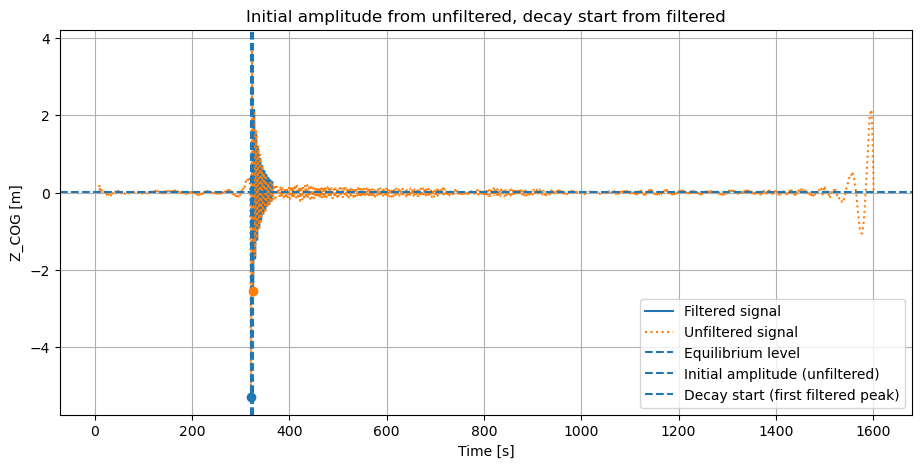

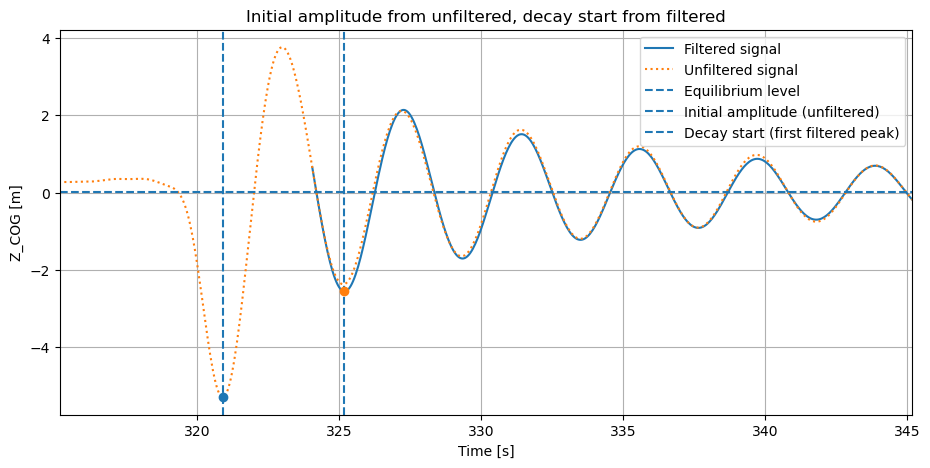

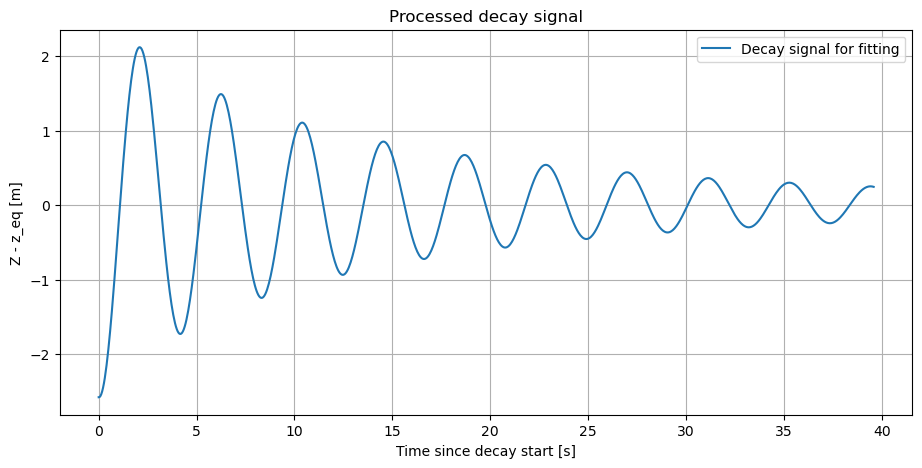

In [82]:
plt.figure(figsize=(11, 5))
plt.plot(t_filt, z_filt, label="Filtered signal")
plt.plot(t_unfiltered, z_unfiltered, ":", label="Unfiltered signal")
plt.axhline(z_eq, linestyle="--", label="Equilibrium level")
plt.axvline(t_init, linestyle="--", label="Initial amplitude (unfiltered)")
plt.axvline(t_decay_start, linestyle="--", label="Decay start (first filtered peak)")
plt.scatter([t_init], [z_init], zorder=5)
plt.scatter([t_decay_start], [z_decay_start], zorder=5)
plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
# plt.xlim(t_decay_start - 10, t_decay_start + 20)
plt.title("Initial amplitude from unfiltered, decay start from filtered")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(t_filt, z_filt, label="Filtered signal")
plt.plot(t_unfiltered, z_unfiltered, ":", label="Unfiltered signal")
plt.axhline(z_eq, linestyle="--", label="Equilibrium level")
plt.axvline(t_init, linestyle="--", label="Initial amplitude (unfiltered)")
plt.axvline(t_decay_start, linestyle="--", label="Decay start (first filtered peak)")
plt.scatter([t_init], [z_init], zorder=5)
plt.scatter([t_decay_start], [z_decay_start], zorder=5)
plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.xlim(t_decay_start - 10, t_decay_start + 20)
plt.title("Initial amplitude from unfiltered, decay start from filtered")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(t_decay, z_decay, label="Decay signal for fitting")
plt.xlabel("Time since decay start [s]")
plt.ylabel("Z - z_eq [m]")
plt.title("Processed decay signal")
plt.grid(True)
plt.legend()
plt.show()

In [83]:
from scipy.signal import find_peaks
import numpy as np

def shift_signal_to_first_extremum_after_start(t, z, positive=True, prominence=None):
    """
    Verschuif signaal zodat het eerste top/dal NA de initiële amplitude op t=0 komt.

    Parameters
    ----------
    t : array
        Tijdreeks, met t[0] op initiële amplitude.
    z : array
        Signaal.
    positive : bool
        True  -> zoek eerste top
        False -> zoek eerste dal
    prominence : float or None
        Optioneel voor robuustere detectie.

    Returns
    -------
    t_shift : np.ndarray
    z_shift : np.ndarray
        Signaal gecropt vanaf het eerste overeenkomstige extremum,
        met dat extremum op t=0.
    idx_first : int
        Index van het eerste gevonden extremum in het originele signaal.
    """
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) < 2:
        raise ValueError("Signaal is te kort.")

    # zoek alleen NA het beginpunt
    t_rest = t[1:]
    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx_local, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx_local, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx_local) == 0:
        raise ValueError("Geen overeenkomstig extremum gevonden na initiële amplitude.")

    idx_first = idx_local[0] + 1   # +1 omdat we in t[1:], z[1:] zochten

    t_shift = t[idx_first:] - t[idx_first]
    z_shift = z[idx_first:]

    return t_shift, z_shift, idx_first

In [84]:
def get_n_extrema_including_start(t, z, n=3, positive=True, prominence=None):
    """
    Neem het startpunt mee als eerste extremum en zoek daarna nog n-1 extrema.
    """
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) == 0:
        raise ValueError("Leeg signaal.")
    if n < 1:
        raise ValueError("n moet minstens 1 zijn.")

    t_ext = [t[0]]
    z_ext = [z[0]]

    if n == 1:
        return np.array(t_ext), np.array(z_ext)

    t_rest = t[1:]
    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx) < n - 1:
        raise ValueError(f"Te weinig extrema gevonden: {len(idx)+1} incl. start, {n} nodig.")

    idx = idx[:n-1]

    t_ext.extend(t_rest[idx])
    z_ext.extend(z_rest[idx])

    return np.array(t_ext), np.array(z_ext)

fit_positive = A0_signed >= 0
prom = 0.01 * abs(z_decay[0]) if abs(z_decay[0]) > 0 else None

t_ref, z_ref = get_n_extrema_including_start(
    t_decay,
    z_decay,
    n=3,
    positive=fit_positive,
    prominence=prom
)

print("Referentie-extrema uit experiment:")
for i, (tt, zz) in enumerate(zip(t_ref, z_ref), start=1):
    kind = "top" if fit_positive else "dal"
    print(f"{kind} {i}: t = {tt:.4f} s, z = {zz:.6f} m")

Referentie-extrema uit experiment:
dal 1: t = 0.0000 s, z = -2.579803 m
dal 2: t = 4.1686 s, z = -1.730123 m
dal 3: t = 8.3371 s, z = -1.245084 m


In [85]:
model = OrcFxAPI.Model(model_path)
constraint = model["decay_constraint"]
floaters = model["floaters"]
floatertype = model["Floatertype"]


In [86]:
def compute_extrema_rmse_z(z_sim_ext, z_exp_ext):
    """
    Genormaliseerde RMSE op z-extrema.
    """
    z_sim_ext = np.asarray(z_sim_ext)
    z_exp_ext = np.asarray(z_exp_ext)

    if len(z_sim_ext) != len(z_exp_ext):
        raise ValueError("Lengtes van z-extrema komen niet overeen.")

    scale = max(np.mean(np.abs(z_exp_ext)), 1e-6)
    nrmse_z = np.sqrt(np.mean(((z_sim_ext - z_exp_ext) / scale)**2))
    return nrmse_z

In [87]:
def run_decay_simulation(c_lin, c_quad, A0_sim, model_path=model_path):
    """
    Draai 1 OrcaFlex decay-simulatie voor gegeven damping.
    
    Returns
    -------
    t_sim : np.ndarray
    z_sim : np.ndarray
        Z-signaal gecentreerd rond het simulatie-evenwicht indien nodig.
    """

    # ------------------------------------------------------
    # 1. model laden / resetten
    # ------------------------------------------------------
    # PAS DIT AAN NAAR JOUW EIGEN MODEL
    model = OrcFxAPI.Model(model_path)
    constraint = model["decay_constraint"]
    floaters = model["floaters"]
    floatertype = model["Floatertype"]
        # <-- aanpassen als jij die gebruikt

    # ------------------------------------------------------
    # 2. damping zetten
    # ------------------------------------------------------
    floatertype.OtherDampingLinearCoeffz = c_lin
    floatertype.OtherDampingQuadraticCoeffz = c_quad

    # ------------------------------------------------------
    # 3. initiële amplitude gelijk maken aan experiment
    # ------------------------------------------------------
    # ALS jouw decay via constraint-offset wordt opgelegd:
    constraint.InFrameInitialZ = A0_signed

    # Als je model anders is opgezet, moet je hier jouw eigen
    # initial condition methode gebruiken.

    # ------------------------------------------------------
    # 4. simulatie draaien
    # ------------------------------------------------------
    model.RunSimulation()

    t_sim = model.general.TimeHistory("Time")

    # ------------------------------------------------------
    # 5. time history ophalen
    # ------------------------------------------------------
    t_sim = np.array(model.general.TimeHistory("Time"))
    z_sim_raw = np.array(floaters.TimeHistory("Z"))

    # ------------------------------------------------------
    # 6. signaal centreren
    # ------------------------------------------------------
    # Omdat absolute nulpunten vaak verschillen:
    # neem het gemiddelde van laatste stuk als evenwicht
    n_tail = min(100, len(z_sim_raw))
    z_eq_sim = np.mean(z_sim_raw[-n_tail:])

    z_sim = z_sim_raw - z_eq_sim

    # tijd op 0 laten beginnen
    t_sim = t_sim - t_sim[0]

    return t_sim, z_sim

In [88]:
# def run_grid_search(lin_values, quad_values):
#     results = []
#     best_score = np.inf
#     best = None

#     for c_lin in lin_values:
#         for c_quad in quad_values:
#             try:
#                 t_sim, z_sim = run_decay_simulation(c_lin, c_quad, A0_sim, model_path)

#                 # verschuiven naar eerste extremum
#                 t_sim_shift, z_sim_shift, _ = shift_signal_to_first_extremum_after_start(
#                     t_sim,
#                     z_sim,
#                     positive=fit_positive,
#                     prominence=prom
#                 )

#                 # extrema pakken
#                 t_sim_ext, z_sim_ext = get_n_extrema_including_start(
#                     t_sim_shift,
#                     z_sim_shift,
#                     n=3,
#                     positive=fit_positive,
#                     prominence=prom
#                 )

#                 # score (alleen z)
#                 score = compute_extrema_rmse_z(z_sim_ext, z_ref)

#                 results.append((c_lin, c_quad, score))

#                 if score < best_score:
#                     best_score = score
#                     best = (c_lin, c_quad)

#             except Exception:
#                 results.append((c_lin, c_quad, np.nan))

#     return best, best_score, results

def run_grid_search(lin_values, quad_values):
    results = []
    best_score = np.inf
    best = None

    for c_lin in lin_values:
        for c_quad in quad_values:
            try:
                t_sim, z_sim = run_decay_simulation(c_lin, c_quad, A0_signed, model_path)

                t_sim_shift, z_sim_shift, _ = shift_signal_to_first_extremum_after_start(
                    t_sim,
                    z_sim,
                    positive=fit_positive,
                    prominence=prom
                )

                t_sim_ext, z_sim_ext = get_n_extrema_including_start(
                    t_sim_shift,
                    z_sim_shift,
                    n=3,
                    positive=fit_positive,
                    prominence=prom
                )

                score = compute_extrema_rmse_z(z_sim_ext, z_ref)

                print(f"lin={c_lin:.3f}, quad={c_quad:.3f}, score={score}")

                results.append((c_lin, c_quad, score))

                if np.isfinite(score) and score < best_score:
                    best_score = score
                    best = (c_lin, c_quad)

            except Exception as e:
                print(f"FOUT bij lin={c_lin:.3f}, quad={c_quad:.3f}: {e}")
                results.append((c_lin, c_quad, np.nan))

    return best, best_score, results

In [89]:
lin_values = np.linspace(0, 10, 10)
quad_values = np.linspace(0, 10, 10)

best_coarse, score_coarse, results_coarse = run_grid_search(lin_values, quad_values)


if best_coarse is None:
    print("Geen geldige beste combinatie gevonden.")
else:
    best_lin, best_quad = best_coarse
    print(f"Coarse best: lin={best_lin:.3f}, quad={best_quad:.3f}, score={score_coarse:.6f}")

lin=0.000, quad=0.000, score=1.7216463074502293
lin=0.000, quad=1.111, score=0.9434811239234041
lin=0.000, quad=2.222, score=0.5110454933051665
lin=0.000, quad=3.333, score=0.2403971035063162
lin=0.000, quad=4.444, score=0.05265297712691574
lin=0.000, quad=5.556, score=0.08887868907091771
lin=0.000, quad=6.667, score=0.1960487468381386
lin=0.000, quad=7.778, score=0.2825355551998014
lin=0.000, quad=8.889, score=0.35197560535625894
lin=0.000, quad=10.000, score=0.4105915296442959
lin=1.111, quad=0.000, score=1.623826142225701
lin=1.111, quad=1.111, score=0.8611711442264082
lin=1.111, quad=2.222, score=0.454058223214207
lin=1.111, quad=3.333, score=0.19700035950883957
lin=1.111, quad=4.444, score=0.019504023992552688
lin=1.111, quad=5.556, score=0.11775512490530703
lin=1.111, quad=6.667, score=0.22092673613538083
lin=1.111, quad=7.778, score=0.30415710905235
lin=1.111, quad=8.889, score=0.37133890369457
lin=1.111, quad=10.000, score=0.4281294250809097
lin=2.222, quad=0.000, score=1.49928

In [90]:
delta_lin = 1 
delta_quad = 1

lin_min = max(0, best_lin - delta_lin)
lin_max = best_lin + delta_lin

quad_min = max(0, best_quad - delta_quad)
quad_max = best_quad + delta_quad

lin_values_refined = np.linspace(lin_min, lin_max, 15)
quad_values_refined = np.linspace(quad_min, quad_max, 15)

In [91]:
best_refined, score_refined, results_refined = run_grid_search(
    lin_values_refined,
    quad_values_refined
)

best_lin_ref, best_quad_ref = best_refined

print(f"Refined best: lin={best_lin_ref:.4f}, quad={best_quad_ref:.4f}, score={score_refined:.6f}")

lin=0.111, quad=3.444, score=0.2143336951119496
lin=0.111, quad=3.587, score=0.18756673588613698
lin=0.111, quad=3.730, score=0.1619605140648962
lin=0.111, quad=3.873, score=0.1374236597197017
lin=0.111, quad=4.016, score=0.11390658732855626
lin=0.111, quad=4.159, score=0.09135985370281731
lin=0.111, quad=4.302, score=0.06975758183515271
lin=0.111, quad=4.444, score=0.04913857428115264
lin=0.111, quad=4.587, score=0.029964233001523108
lin=0.111, quad=4.730, score=0.014045157129155302
lin=0.111, quad=4.873, score=0.015160997455355308
lin=0.111, quad=5.016, score=0.030365321587397038
lin=0.111, quad=5.159, score=0.04698709547768171
lin=0.111, quad=5.302, score=0.06346320494043976
lin=0.111, quad=5.444, score=0.0795516320349802
lin=0.254, quad=3.444, score=0.20882958100686802
lin=0.254, quad=3.587, score=0.1822223545931055
lin=0.254, quad=3.730, score=0.15676741950846496
lin=0.254, quad=3.873, score=0.1323742385190018
lin=0.254, quad=4.016, score=0.10899393758338877
lin=0.254, quad=4.159,

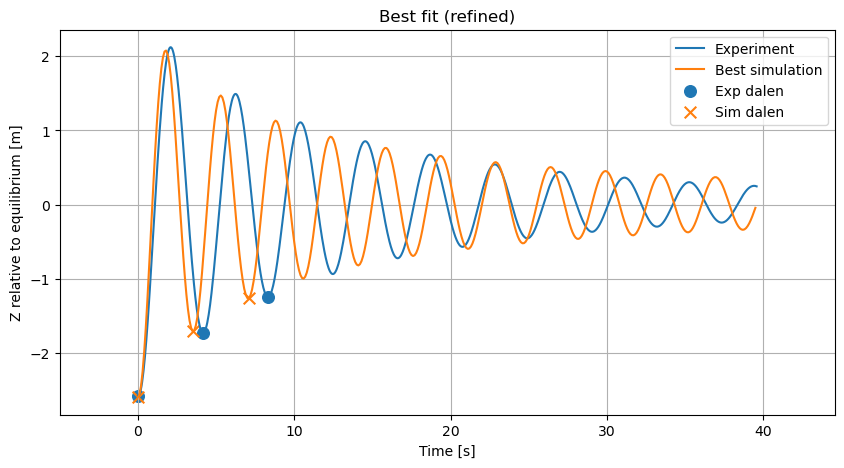

In [92]:
best_lin, best_quad = best_refined



# opnieuw simulatie draaien met beste parameters
t_sim, z_sim = run_decay_simulation(best_lin, best_quad, A0_signed, model_path)

# verschuiven naar eerste extremum
t_sim_shift, z_sim_shift, _ = shift_signal_to_first_extremum_after_start(
    t_sim,
    z_sim,
    positive=fit_positive,
    prominence=prom
)

# extrema pakken
t_sim_ext, z_sim_ext = get_n_extrema_including_start(
    t_sim_shift,
    z_sim_shift,
    n=3,
    positive=fit_positive,
    prominence=prom
)

# truncate simulation to match experiment time range
t_max = t_decay[-1]
mask_sim = t_sim_shift <= t_max
t_sim_plot = t_sim_shift[mask_sim]
z_sim_plot = z_sim_shift[mask_sim]

# plot
plt.figure(figsize=(10, 5))
plt.plot(t_decay, z_decay, label="Experiment")
plt.plot(t_sim_plot, z_sim_plot, label="Best simulation")

label_name = "toppen" if fit_positive else "dalen"

plt.scatter(t_ref, z_ref, s=70, label=f"Exp {label_name}")
plt.scatter(t_sim_ext, z_sim_ext, s=70, marker="x", label=f"Sim {label_name}")

plt.xlabel("Time [s]")
plt.ylabel("Z relative to equilibrium [m]")
plt.title("Best fit (refined)")
plt.xlim(-5, t_decay[-1]+5)
plt.grid(True)
plt.legend()
plt.show()



In [94]:
rmse = compute_extrema_rmse_z(z_sim_ext, z_ref)

# =========================
# 2. Functie om periode te bepalen
# =========================
def compute_period(signal_t, signal_z, positive=True, prominence=0.01):
    if positive:
        idx, _ = find_peaks(signal_z, prominence=prominence)
    else:
        idx, _ = find_peaks(-signal_z, prominence=prominence)

    if len(idx) < 2:
        return np.nan, idx

    periods = np.diff(signal_t[idx])
    return np.mean(periods), idx

# periode experiment
T_exp, idx_exp = compute_period(
    t_decay,
    z_decay,
    positive=fit_positive,
    prominence=prom
)

# periode simulatie
T_sim, idx_sim = compute_period(
    t_sim_shift,
    z_sim_shift,
    positive=fit_positive,
    prominence=prom
)


In [95]:
df_summary = pd.DataFrame({
    "Grootheid": [
        "Linear damping coefficient",
        "Quadratic damping coefficient",
        "Initial amplitude",
        "Period experiment [s]",
        "Period simulation [s]",
        "RMSE"
    ],
    "Waarde": [
        best_lin,
        best_quad,
        A0_signed,
        T_exp,
        T_sim,
        rmse
    ]
})

print(df_summary)

                       Grootheid    Waarde
0     Linear damping coefficient  0.968254
1  Quadratic damping coefficient  4.587302
2              Initial amplitude -5.325702
3          Period experiment [s]  4.146144
4          Period simulation [s]  3.517647
5                           RMSE  0.010276
